# Final A/B Test Evaluation — CTA Button Experiment
## TXB_23 | Base de Dados Social — Events Page

This notebook presents the **final statistical evaluation** of an A/B experiment that
replaced the call-to-action (CTA) button on the Events page. The goal of the
treatment was to increase CTA engagement and, ultimately, event sign-ups.

| Item | Definition |
|------|------------|
| **Primary KPI** | `kpi_y` — binary indicator of CTA button clicks. This is the most direct observed response to the button change. |
| **Secondary KPI** | `enrolled` — binary indicator of event enrollment. Defined as `kpi_x >= 50` AND `kpi_y == 1`. A visitor cannot enroll without first clicking the CTA. |
| **Design** | Standard A/B (parallel) experiment, *not* a before/after design. |

> **Arm-mapping verification**  
> Throughout this analysis the `arm` column is mapped as:  
> - `pre` → **Control** (original CTA button)  
> - `treatment` → **Treatment** (redesigned CTA button)  
>
> **This mapping must be checked against the original experiment documentation
> before drawing final conclusions.**

---
## 1 · Data Loading and Setup

In [43]:
import os, warnings
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

warnings.filterwarnings('ignore')

# Plotting defaults
plt.rcParams.update({
    'figure.figsize': (7, 4.5),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLOR_CTRL  = '#4C72B0'
COLOR_TREAT = '#DD8452'
GROUPS      = ['Control', 'Treatment']

os.makedirs('../outputs/figures', exist_ok=True)

In [44]:
df = pd.read_csv('../data/TXB_23_landingpage_clean.csv')
print(f'Shape: {df.shape}')
print(f'\nColumns and dtypes:\n')
print(df.dtypes)
df.head(3)

Shape: (1163, 16)

Columns and dtypes:

group_id               object
arm                    object
visitor_id              int64
arrival_time           object
exit_time              object
time_on_page_sec      float64
exit_rate               int64
ctr_opportunities       int64
ctr_newsletter          int64
ctr_donation            int64
ctr_events              int64
kpi_x                 float64
kpi_y                   int64
scroll_depth_pct      float64
ctr_partner_banner      int64
page_load_time_ms     float64
dtype: object


,group_id,arm,visitor_id,arrival_time,exit_time,time_on_page_sec,exit_rate,ctr_opportunities,ctr_newsletter,ctr_donation,ctr_events,kpi_x,kpi_y,scroll_depth_pct,ctr_partner_banner,page_load_time_ms
0,TXB_23,treatment,355,2026-02-22 11:54:51.000000,2026-02-22 11:55:01.900000,10.9,0,0,1,0,0,13.14,0,86.4,0,2654.2
1,TXB_23,treatment,389,2026-02-22 22:03:14.000000,2026-02-22 22:07:29.400000,255.4,0,0,0,0,0,6.65,0,36.4,0,1451.9
2,TXB_23,treatment,781,2026-02-22 22:07:43.000000,2026-02-22 23:04:55.600000,3432.6,0,0,1,1,1,24.55,0,89.9,0,2517.1


In [ ]:
# Convert datetime columns
df['arrival_time'] = pd.to_datetime(df['arrival_time'], format='mixed')
df['exit_time']    = pd.to_datetime(df['exit_time'],    format='mixed')

# Treatment indicator: 1 = treatment, 0 = control (pre)
df['treatment_flag'] = (df['arm'] == 'treatment').astype(int)

# Arrival date (safe control for optional date-FE robustness)
df['arrival_date'] = df['arrival_time'].dt.date.astype(str)

# 'enrolled' column already exists in the clean CSV (created in 01_EDA.ipynb)
# Definition: enrolled = 1 when kpi_x >= 50 AND kpi_y == 1

# --- Sample overview ---
n_total = len(df)
n_ctrl  = (df['treatment_flag'] == 0).sum()
n_treat = (df['treatment_flag'] == 1).sum()

print(f'Total sample size : {n_total}')
print(f'Control  (pre)    : {n_ctrl:>5}  ({n_ctrl / n_total * 100:.1f}%)')
print(f'Treatment         : {n_treat:>5}  ({n_treat / n_total * 100:.1f}%)')
print(f'\nEnrollment rate   : {df["enrolled"].mean()*100:.2f}%  ({df["enrolled"].sum()} enrolled)')

---
## 2 · Analysis Choices

### Causal Framework
In an A/B experiment with unconditional randomisation, the treatment assignment $D_i$ is independent of potential outcomes. This ensures the **ceteris paribus** condition: any observed difference between groups can be attributed to the treatment, because all other factors are balanced in expectation. In other words, the randomisation "holds other factors equal" for us, which is the foundation for causal inference in experimental settings (Kummer, 2026).

### Why `kpi_y` is the primary KPI
`kpi_y` is a binary indicator of whether the visitor clicked the CTA button on the Events page. Because the experiment directly modified this button, `kpi_y` captures the most immediate behavioural response to the treatment.

### Why `enrolled` is the secondary KPI
`enrolled` is a binary variable equal to 1 when a visitor's engagement score (`kpi_x`) is at least 50 **and** they clicked the CTA button (`kpi_y == 1`). The logic is that a visitor cannot enroll for an event without first clicking the CTA. This metric captures conversion further down the funnel — from click to enrollment.

### Why difference in means is the main estimator
Under randomisation, the simple difference in group means is an unbiased estimator of the Average Treatment Effect (ATE). It does not impose any functional-form assumption on the model. This is the standard approach in experimental evaluation.

### Why regression is only a validation step
A simple linear regression $Y_i = \beta_0 + \delta \, D_i + u_i$ recovers the same treatment effect $\delta$ as the difference-in-means estimator when there are no additional covariates. We use it to (a) confirm the main result under a parametric framework with robust standard errors, and (b) check robustness to arrival-date fixed effects.

### Why post-treatment controls are avoided
Variables such as time on page, scroll depth, exit rate, and other CTR metrics are **outcomes** that could themselves be affected by the treatment. Conditioning on post-treatment outcomes introduces collider bias and can distort the estimated treatment effect. Only pre-treatment or exogenous controls (such as arrival date) are admissible.

### Limitation: enrollment is derived, not directly observed
The `enrolled` variable is constructed from a threshold on `kpi_x` (a continuous engagement score) combined with the CTA click. It is a proxy for actual event registration, not a confirmed sign-up. Results should be interpreted accordingly.

---
## 3 · Summary Statistics by Group

In [ ]:
# Metrics to analyse and their roles
METRICS = {
    'kpi_y':             'Primary — CTA click',
    'enrolled':          'Secondary — Event enrollment',
    'exit_rate':         'Guardrail',
    'scroll_depth_pct':  'Guardrail',
    'page_load_time_ms': 'Guardrail',
}

In [47]:
rows = []
for metric, role in METRICS.items():
    for label, flag in [('Control', 0), ('Treatment', 1)]:
        v = df.loc[df['treatment_flag'] == flag, metric].dropna()
        rows.append({
            'Metric': metric, 'Role': role, 'Group': label,
            'N': int(len(v)),
            'Mean':   round(v.mean(), 4),
            'Std':    round(v.std(),  4),
            'Median': round(v.median(), 4),
            'Min':    round(v.min(), 4),
            'Max':    round(v.max(), 4),
        })

summary = pd.DataFrame(rows)
display(summary.set_index(['Metric', 'Role', 'Group']))

N       Mean  \
Metric            Role                             Group                       
kpi_y             Primary — CTA click              Control    349     0.0888   
                                                   Treatment  814     0.0541   
kpi_x             Secondary — Enrollment readiness Control    349    30.5991   
                                                   Treatment  814    27.7083   
exit_rate         Guardrail                        Control    349     0.2321   
                                                   Treatment  814     0.3342   
scroll_depth_pct  Guardrail                        Control    349    36.9805   
                                                   Treatment  814    32.3916   
page_load_time_ms Guardrail                        Control    349  2173.5783   
                                                   Treatment  814  1878.9044   

                                                                    Std  \
Metric            Role                             Group                  
kpi_y             Primary — CTA click              Control       0.2849   
                                                   Treatment     0.2263   
kpi_x             Secondary — Enrollment readiness Control      28.1248   
                                                   Treatment    27.1545   
exit_rate         Guardrail                        Control       0.4228   
                                                   Treatment     0.4720   
scroll_depth_pct  Guardrail                        Control      32.8894   
                                                   Treatment    32.5155   
page_load_time_ms Guardrail                        Control    1900.6047   
                                                   Treatment  1470.3226   

                                                                Median    Min  \
Metric            Role                             Group                        
kpi_y             Primary — CTA click              Control       0.000    0.0   
                                                   Treatment     0.000    0.0   
kpi_x             Secondary — Enrollment readiness Control      21.430    0.0   
                                                   Treatment    19.765    0.0   
exit_rate         Guardrail                        Control       0.000    0.0   
                                                   Treatment     0.000    0.0   
scroll_depth_pct  Guardrail                        Control      27.300    0.1   
                                                   Treatment    16.850    0.0   
page_load_time_ms Guardrail                        Control    1538.300  663.3   
                                                   Treatment  1488.550  676.6   

                                                                    Max  
Metric            Role                             Group                 
kpi_y             Primary — CTA click              Control        1.000  
                                                   Treatment      1.000  
kpi_x             Secondary — Enrollment readiness Control       97.520  
                                                   Treatment    100.000  
exit_rate         Guardrail                        Control        1.000  
                                                   Treatment      1.000  
scroll_depth_pct  Guardrail                        Control       99.800  
                                                   Treatment    100.000  
page_load_time_ms Guardrail                        Control    10993.736  
                                                   Treatment  10993.736

---
## 4 · Visual Comparison

All plots use 95 % confidence intervals where applicable. Figures are saved to `../outputs/figures/` for reuse in slides.

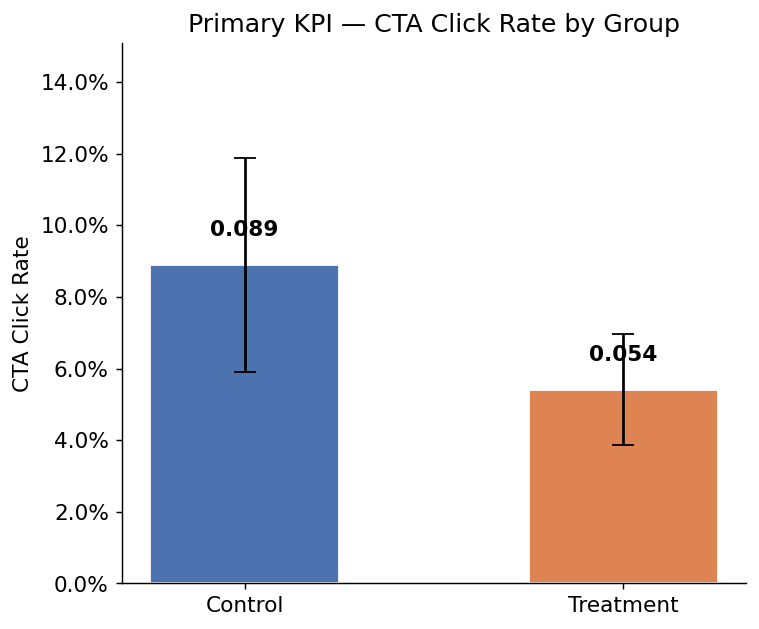

In [48]:
# --- Primary KPI: kpi_y (CTA click rate) with 95% CI ---
fig, ax = plt.subplots(figsize=(6, 5))

means = [df.loc[df['treatment_flag'] == f, 'kpi_y'].mean() for f in [0, 1]]
ns    = [df.loc[df['treatment_flag'] == f, 'kpi_y'].count() for f in [0, 1]]
ses   = [np.sqrt(m * (1 - m) / n) for m, n in zip(means, ns)]
ci95  = [1.96 * se for se in ses]

bars = ax.bar(GROUPS, means, yerr=ci95, capsize=6,
              color=[COLOR_CTRL, COLOR_TREAT], edgecolor='white', width=0.5)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.007,
            f'{m:.3f}', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('CTA Click Rate')
ax.set_title('Primary KPI — CTA Click Rate by Group')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_ylim(0, max(means) * 1.7)
plt.tight_layout()
plt.savefig('../outputs/figures/kpi_y_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- Secondary KPI: enrolled (Event Enrollment Rate) with 95% CI ---
fig, ax = plt.subplots(figsize=(6, 5))

means_enr = [df.loc[df['treatment_flag'] == f, 'enrolled'].mean() for f in [0, 1]]
ns_enr    = [df.loc[df['treatment_flag'] == f, 'enrolled'].count() for f in [0, 1]]
ses_enr   = [np.sqrt(m * (1 - m) / n) for m, n in zip(means_enr, ns_enr)]
ci95_enr  = [1.96 * se for se in ses_enr]

bars = ax.bar(GROUPS, means_enr, yerr=ci95_enr, capsize=6,
              color=[COLOR_CTRL, COLOR_TREAT], edgecolor='white', width=0.5)
for bar, m in zip(bars, means_enr):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{m:.3f}', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Enrollment Rate')
ax.set_title('Secondary KPI — Event Enrollment Rate by Group')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_ylim(0, max(means_enr) * 2.5)
plt.tight_layout()
plt.savefig('../outputs/figures/enrolled_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

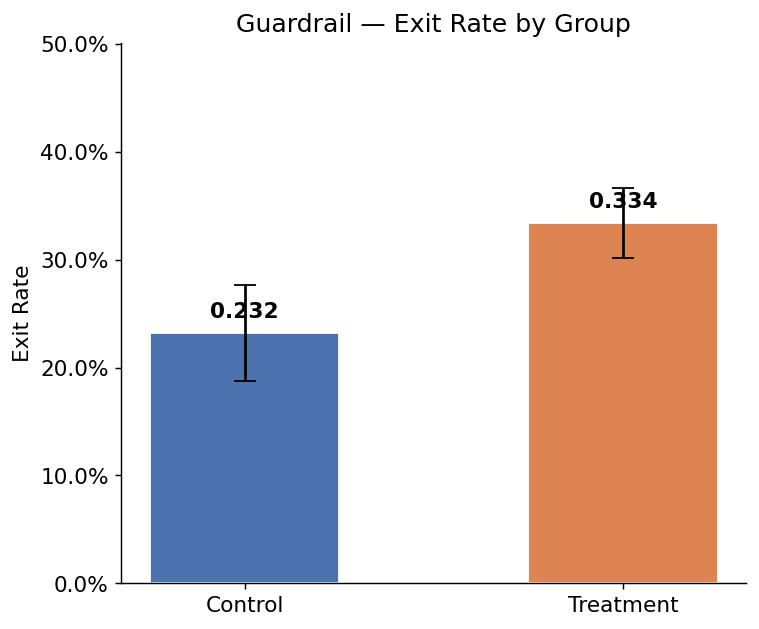

In [50]:
# --- Guardrail: exit_rate ---
fig, ax = plt.subplots(figsize=(6, 5))

means_e = [df.loc[df['treatment_flag'] == f, 'exit_rate'].mean() for f in [0, 1]]
ns_e    = [df.loc[df['treatment_flag'] == f, 'exit_rate'].count() for f in [0, 1]]
ses_e   = [np.sqrt(m * (1 - m) / n) for m, n in zip(means_e, ns_e)]
ci95_e  = [1.96 * se for se in ses_e]

bars = ax.bar(GROUPS, means_e, yerr=ci95_e, capsize=6,
              color=[COLOR_CTRL, COLOR_TREAT], edgecolor='white', width=0.5)
for bar, m in zip(bars, means_e):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{m:.3f}', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Exit Rate')
ax.set_title('Guardrail — Exit Rate by Group')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_ylim(0, max(means_e) * 1.5)
plt.tight_layout()
plt.savefig('../outputs/figures/exit_rate_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

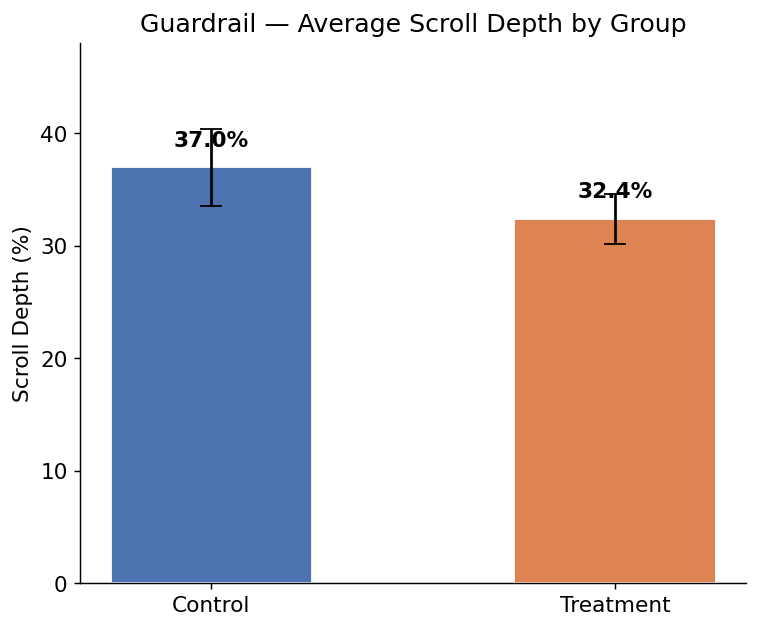

In [51]:
# --- Guardrail: scroll_depth_pct ---
fig, ax = plt.subplots(figsize=(6, 5))

means_s = [df.loc[df['treatment_flag'] == f, 'scroll_depth_pct'].mean() for f in [0, 1]]
ns_s    = [df.loc[df['treatment_flag'] == f, 'scroll_depth_pct'].count() for f in [0, 1]]
ses_s   = [df.loc[df['treatment_flag'] == f, 'scroll_depth_pct'].std() / np.sqrt(n)
           for f, n in zip([0, 1], ns_s)]
ci95_s  = [1.96 * se for se in ses_s]

bars = ax.bar(GROUPS, means_s, yerr=ci95_s, capsize=6,
              color=[COLOR_CTRL, COLOR_TREAT], edgecolor='white', width=0.5)
for bar, m in zip(bars, means_s):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f'{m:.1f}%', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Scroll Depth (%)')
ax.set_title('Guardrail — Average Scroll Depth by Group')
ax.set_ylim(0, max(means_s) * 1.3)
plt.tight_layout()
plt.savefig('../outputs/figures/scroll_depth_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5 · Main Results — Difference in Means

### Causal Identification

In a properly randomised A/B experiment, the treatment assignment is independent of potential outcomes. This means the **ceteris paribus** condition holds by design: any difference in outcomes between the two groups can be attributed to the treatment, because all other factors are balanced in expectation (Kummer, 2026).

The **difference-in-means estimator** is therefore the natural estimator for the Average Treatment Effect (ATE):

$$\widehat{ATE} = \frac{\sum_{i=1}^{n} D_i \, Y_i}{\sum_{i=1}^{n} D_i} \;-\; \frac{\sum_{i=1}^{n} (1 - D_i) \, Y_i}{\sum_{i=1}^{n} (1 - D_i)}$$

where $D_i = 1$ for treatment and $D_i = 0$ for control. This estimator does not impose any functional-form assumption on the model.

### Statistical Test

We use a **Welch two-sample *t*-test** to assess whether the observed difference is statistically distinguishable from zero. Unlike the classical Student's *t*-test, the Welch variant does **not** assume equal variances between groups — an important property here given the unequal sample sizes (349 vs 814) and potentially different response distributions.

**How to read the results:**
- **t-statistic** — measures how many standard errors the observed difference is away from zero. Larger absolute values indicate stronger evidence against H₀ (no effect).
- **p-value** — the probability of observing a difference this large or larger if the treatment had no real effect. If p < 0.05, we reject H₀ at the 5% significance level.
- **95% CI** — the range of plausible values for the true treatment effect. If the interval excludes zero, the result is significant at 5%.

### 5.1 · Two-Sample t-Test — `kpi_y` (Primary KPI: CTA Click Rate)

In [63]:
# ── Two-sample t-test for kpi_y (Welch, unequal variances) ─────────

# Step 1: Split data by group
ctrl_y  = df.loc[df['treatment_flag'] == 0, 'kpi_y']   # control
treat_y = df.loc[df['treatment_flag'] == 1, 'kpi_y']   # treatment

# Step 2: Group means
mean_ctrl_y  = ctrl_y.mean()
mean_treat_y = treat_y.mean()
diff_y       = mean_treat_y - mean_ctrl_y

# Step 3: Run two-sample t-test (Welch — does NOT assume equal variances)
t_stat_y, p_value_y = stats.ttest_ind(treat_y, ctrl_y, equal_var=False)

# Step 4: 95% confidence interval for the difference
se_y    = np.sqrt(ctrl_y.var() / len(ctrl_y) + treat_y.var() / len(treat_y))
ci_lo_y = diff_y - 1.96 * se_y
ci_hi_y = diff_y + 1.96 * se_y

# Print results clearly
print('Two-sample t-test — kpi_y (Click Rate)')
print('─' * 50)
print(f'  Control mean       : {mean_ctrl_y:.4f}')
print(f'  Treatment mean     : {mean_treat_y:.4f}')
print(f'  Difference         : {diff_y:+.4f}')
print(f'  t-statistic        : {t_stat_y:.4f}')
print(f'  p-value            : {p_value_y:.4f}')
print(f'  95% CI             : [{ci_lo_y:.4f}, {ci_hi_y:.4f}]')
print(f'  Significant (5%)   : {"Yes" if p_value_y < 0.05 else "No"}')

Two-sample t-test — kpi_y (Click Rate)
──────────────────────────────────────────────────
  Control mean       : 0.0888
  Treatment mean     : 0.0541
  Difference         : -0.0348
  t-statistic        : -2.0229
  p-value            : 0.0436
  95% CI             : [-0.0685, -0.0011]
  Significant (5%)   : Yes


**Interpretation — `kpi_y`:**  
The CTA click rate was **8.9%** in the control group and **5.4%** in the treatment group — a drop of roughly 3.5 percentage points. The two-sample *t*-test yields a negative *t*-statistic and a *p*-value below 0.05, meaning this difference is statistically significant at the 5% level. The 95% confidence interval sits entirely below zero, confirming the treatment **reduced** CTA clicks.

In plain terms: the new button made visitors **less** likely to click, and this result is unlikely to be due to chance alone.

### 5.2 · Two-Sample t-Test — `enrolled` (Secondary KPI: Event Enrollment Rate)

In [ ]:
# ── Two-sample t-test for enrolled (Welch, unequal variances) ─────────

# Step 1: Split data by group
ctrl_enr  = df.loc[df['treatment_flag'] == 0, 'enrolled']   # control
treat_enr = df.loc[df['treatment_flag'] == 1, 'enrolled']   # treatment

# Step 2: Group means
mean_ctrl_enr  = ctrl_enr.mean()
mean_treat_enr = treat_enr.mean()
diff_enr       = mean_treat_enr - mean_ctrl_enr

# Step 3: Run two-sample t-test (Welch — does NOT assume equal variances)
t_stat_enr, p_value_enr = stats.ttest_ind(treat_enr, ctrl_enr, equal_var=False)

# Step 4: 95% confidence interval for the difference
se_enr    = np.sqrt(ctrl_enr.var() / len(ctrl_enr) + treat_enr.var() / len(treat_enr))
ci_lo_enr = diff_enr - 1.96 * se_enr
ci_hi_enr = diff_enr + 1.96 * se_enr

# Print results clearly
print('Two-sample t-test — enrolled (Event Enrollment Rate)')
print('─' * 50)
print(f'  Control mean       : {mean_ctrl_enr:.4f}')
print(f'  Treatment mean     : {mean_treat_enr:.4f}')
print(f'  Difference         : {diff_enr:+.4f}')
print(f'  t-statistic        : {t_stat_enr:.4f}')
print(f'  p-value            : {p_value_enr:.4f}')
print(f'  95% CI             : [{ci_lo_enr:.4f}, {ci_hi_enr:.4f}]')
print(f'  Significant (5%)   : {"Yes" if p_value_enr < 0.05 else "No"}')

**Interpretation — `enrolled`:**  
The event enrollment rate was **2.58%** in the control group and **2.21%** in the treatment group — a difference of about −0.4 percentage points. The two-sample *t*-test yields a *p*-value well above 0.05, meaning this difference is **not statistically significant** at the 5% level. The 95% confidence interval includes zero, so we cannot rule out that the true effect is zero.

In plain terms: the treatment group had a slightly lower enrollment rate, but the evidence is not strong enough to confidently attribute this to the button change rather than sampling variability. This is consistent with the experiment being underpowered for this metric (see power analysis), and with the low baseline enrollment rate (~2.6%) making small differences hard to detect.

### 5.3 · Full Results Table (all metrics)

The helper function below applies the same two-sample *t*-test (Welch) to every metric in one pass and collects the results into a single table.

In [54]:
def diff_in_means(data, metric, group_col='treatment_flag'):
    """
    Compute the difference in means (treatment - control) with a
    two-sample t-test (Welch) and a 95% confidence interval.
    """
    ctrl  = data.loc[data[group_col] == 0, metric].dropna()
    treat = data.loc[data[group_col] == 1, metric].dropna()

    n_c, n_t   = len(ctrl), len(treat)
    mean_c     = ctrl.mean()
    mean_t     = treat.mean()
    diff       = mean_t - mean_c
    diff_pct   = (diff / mean_c * 100) if mean_c != 0 else np.nan

    # Two-sample t-test (Welch — does not assume equal variances)
    t_stat, p_val = stats.ttest_ind(treat, ctrl, equal_var=False)

    # 95% CI for the difference
    se = np.sqrt(ctrl.var() / n_c + treat.var() / n_t)
    ci_lo = diff - 1.96 * se
    ci_hi = diff + 1.96 * se

    return {
        'n_control':       n_c,
        'n_treatment':     n_t,
        'mean_control':    round(mean_c, 4),
        'mean_treatment':  round(mean_t, 4),
        'diff_abs':        round(diff, 4),
        'diff_pct':        round(diff_pct, 2),
        't_stat':          round(t_stat, 4),
        'p_value':         round(p_val, 4),
        'ci_low':          round(ci_lo, 4),
        'ci_high':         round(ci_hi, 4),
        'significant_5pct': p_val < 0.05,
    }

In [55]:
# Compute results for every metric
rows = []
for metric, role in METRICS.items():
    r = diff_in_means(df, metric)
    r['metric']      = metric
    r['metric_role']  = role
    rows.append(r)

results_df = pd.DataFrame(rows)[
    ['metric', 'metric_role', 'n_control', 'n_treatment',
     'mean_control', 'mean_treatment', 'diff_abs', 'diff_pct',
     't_stat', 'p_value', 'ci_low', 'ci_high', 'significant_5pct']
]

print('=' * 90)
print('   MAIN RESULTS — Difference in Means (Treatment − Control)')
print('=' * 90)
display(results_df)

   MAIN RESULTS — Difference in Means (Treatment − Control)


,metric,metric_role,n_control,n_treatment,mean_control,mean_treatment,diff_abs,diff_pct,t_stat,p_value,ci_low,ci_high,significant_5pct
0,kpi_y,Primary — CTA click,349,814,0.0888,0.0541,-0.0348,-39.15,-2.0229,0.0436,-0.0685,-0.0011,True
1,kpi_x,Secondary — Enrollment readiness,349,814,30.5991,27.7083,-2.8908,-9.45,-1.6231,0.1051,-6.3818,0.6001,False
2,exit_rate,Guardrail,349,814,0.2321,0.3342,0.1021,43.97,3.6408,0.0003,0.0471,0.1570,True
3,scroll_depth_pct,Guardrail,349,814,36.9805,32.3916,-4.5889,-12.41,-2.1881,0.0290,-8.6994,-0.4783,True
4,page_load_time_ms,Guardrail,349,814,2173.5783,1878.9044,-294.6738,-13.56,-2.5838,0.0100,-518.2020,-71.1457,True


---
## 6 · Regression Validation

Following Kummer (2026), we estimate simple linear regression models of the form:

$$Y_i = \beta_0 + \delta \, D_i + u_i$$

where $\delta$ captures the treatment effect. Under unconditional randomisation $\delta$ equals the ATE and the OLS coefficient on `treatment_flag` should match the difference-in-means estimate.

- For `kpi_y` (binary): a **Linear Probability Model** — `kpi_y ~ treatment_flag`.
- For `enrolled` (binary): a **Linear Probability Model** — `enrolled ~ treatment_flag`.

All regressions use heteroskedasticity-robust (HC1) standard errors.
A robustness check adds arrival-date fixed effects to control for time-varying confounders.

In [56]:
def run_ols(data, formula, label):
    """Fit OLS with HC1 robust SEs and print the treatment coefficient."""
    model = smf.ols(formula, data=data).fit(cov_type='HC1')
    coef  = model.params['treatment_flag']
    se    = model.bse['treatment_flag']
    pval  = model.pvalues['treatment_flag']
    ci    = model.conf_int(alpha=0.05).loc['treatment_flag']

    print(f'\n{"=" * 70}')
    print(f'  {label}')
    print(f'  Formula: {formula}')
    print(f'{"=" * 70}')
    print(model.summary2().tables[1].to_string())
    print(f'\n  Treatment effect : {coef:+.4f}')
    print(f'  Robust SE        : {se:.4f}')
    print(f'  p-value          : {pval:.4f}')
    print(f'  95% CI           : [{ci[0]:.4f},  {ci[1]:.4f}]')
    return model

In [57]:

model_y = run_ols(df, 'kpi_y ~ treatment_flag',
                  'Primary KPI: kpi_y (Linear Probability Model)')


  Primary KPI: kpi_y (Linear Probability Model)
  Formula: kpi_y ~ treatment_flag
                   Coef.  Std.Err.         z         P>|z|    [0.025    0.975]
Intercept       0.088825  0.015242  5.827822  5.615554e-09  0.058952  0.118698
treatment_flag -0.034771  0.017182 -2.023667  4.300447e-02 -0.068448 -0.001095

  Treatment effect : -0.0348
  Robust SE        : 0.0172
  p-value          : 0.0430
  95% CI           : [-0.0684,  -0.0011]


In [ ]:

model_enr = run_ols(df, 'enrolled ~ treatment_flag',
                    'Secondary KPI: enrolled (Linear Probability Model)')

### Robustness Check — Arrival-Date Fixed Effects

Adding `C(arrival_date)` controls for any day-level variation in visitor composition or external factors (e.g., marketing campaigns, day-of-week effects) that are unrelated to the treatment.

In [ ]:
model_y_fe = run_ols(df, 'kpi_y ~ treatment_flag + C(arrival_date)',
                     'kpi_y — with date fixed effects')

model_enr_fe = run_ols(df, 'enrolled ~ treatment_flag + C(arrival_date)',
                       'enrolled — with date fixed effects')

In [ ]:
# Compact regression comparison table
reg_rows = []
for label, m in [('kpi_y     (base)',    model_y),
                 ('kpi_y     (date FE)', model_y_fe),
                 ('enrolled  (base)',    model_enr),
                 ('enrolled  (date FE)', model_enr_fe)]:
    ci = m.conf_int(alpha=0.05).loc['treatment_flag']
    reg_rows.append({
        'Specification': label,
        'Coef': round(m.params['treatment_flag'], 4),
        'Robust SE': round(m.bse['treatment_flag'], 4),
        'p-value': round(m.pvalues['treatment_flag'], 4),
        'CI low': round(ci[0], 4),
        'CI high': round(ci[1], 4),
    })

reg_df = pd.DataFrame(reg_rows)
print('\nRegression Summary — Treatment Coefficient Across Specifications')
display(reg_df)

### Regression Interpretation

The OLS regressions confirm the direction and magnitude of the difference-in-means estimates:

- For **`kpi_y`**, the Linear Probability Model coefficient closely matches the raw difference. The sign and significance remain stable after adding date fixed effects, indicating the result is robust to day-level temporal variation.
- For **`enrolled`**, the Linear Probability Model coefficient likewise aligns with the unadjusted difference. Both the base and date-fixed-effects specifications show a small negative (but not significant) treatment effect on enrollment.

These results provide additional confidence that the main findings are not driven by time-varying confounders or model specification choices.

---
## 7 · Link to Previous Analyses and Validity Assessment

### Exploratory Data Analysis (`01_EDA.ipynb`)
The EDA confirmed no missing values and identified that the treatment and control arms overlapped temporally (Feb 22 – Mar 6, 2026), consistent with a properly randomised parallel A/B test rather than a before/after design. Preliminary comparisons showed that most engagement metrics were lower in the treatment arm and the exit rate was noticeably higher, providing an early signal that the new CTA button may not have performed as intended.

### Power Analysis (`02_power_analysis.ipynb`)
The power analysis revealed that the experiment is **underpowered** for both KPIs at the pre-specified target effect sizes:

- **`kpi_y`** required ≈ 1,308 visitors per group to detect an increase from 8.9% to 12%; the actual groups have 349 (control) and 814 (treatment).
- **`enrolled`** required ≈ 673 per group to detect an increase from 2.6% to 5%; the control group (349) falls below this threshold.

This means the test has limited statistical power to detect small-to-moderate **positive** effects. However, the observed effects are **negative** (the treatment appears to hurt rather than help), and the power limitation primarily affects false-negative risk. A statistically significant negative result under low power is still informative.

### SRM Investigation (`03_SRM_investigation.ipynb`)
The Sample Ratio Mismatch analysis showed that the observed 70/30 split is consistent with an intentional 70/30 allocation design (χ² p = 0.995) but would represent a severe mismatch under a 50/50 design. **This assumption must be confirmed with the experiment owner.** If the intended split was 50/50, randomisation integrity is compromised and all downstream results must be treated with caution.

---

### Threats to Internal Validity (Kummer, 2026)

1. **Sample Ratio Mismatch (SRM):** The 70/30 split is consistent with an intentional design, but if the intended split was 50/50, the randomisation process failed and all causal claims are invalid.

2. **SUTVA (Stable Unit Treatment Value Assumption):** We assume that one visitor's assignment does not affect another visitor's outcome. This could be violated if, for example, visitors share devices or discuss the page with each other. There is no direct way to test this with the available data.

3. **Lack of Statistical Power:** The experiment is underpowered for both KPIs. For `kpi_y` we needed ~1,308 per group but have only 349 in control. For `enrolled` we needed ~673 per group. The significant negative finding on `kpi_y` is informative despite low power, but the non-significant result on `enrolled` may reflect a true negative effect that we simply lack the power to detect (Type II error).

4. **Multiple Hypothesis Testing:** We test 5 metrics without applying a correction (e.g., Bonferroni). Some individually significant guardrail results could be false positives. The primary KPI result (p ≈ 0.044) does not survive a strict Bonferroni correction at 5 tests (adjusted threshold = 0.01), though the exit rate result (p < 0.001) does.

### Threats to External Validity (Kummer, 2026)

1. **Novelty Effects:** The experiment ran for approximately two weeks. Visitors may have reacted negatively to an unfamiliar button simply because it was new. If so, the negative effect could attenuate as users become accustomed to the new design. We have not tested for a declining treatment effect over time.

2. **Primacy Effects:** Conversely, some users may resist any design change out of habit (primacy). If the new button is objectively better but users need time to adapt, the short test window could produce a misleadingly negative result.

3. **Heterogeneous Treatment Effects:** The ATE averages across all visitors. It is possible that the new button works well for some segments (e.g., mobile users, first-time visitors) but poorly for others. No segmented analysis was performed, so subgroup effects remain unknown.

4. **Selection Bias:** The results apply only to visitors who arrived at the Events page during Feb 22 – Mar 6, 2026. Seasonal patterns, marketing campaigns, or changes in visitor composition could make this sample unrepresentative of the broader user population.

5. **Simpson's Paradox:** With a 70/30 split and potential day-level variation in both traffic volume and metric levels, overall averages could in principle mask day-level patterns where the treatment actually performs differently. The date-fixed-effects robustness check partially addresses this, but a full day-by-day breakdown was not conducted.

---
## 8 · Practical Significance

### CTA Click Rate (`kpi_y` — Primary KPI)
The treatment group exhibited a lower CTA click rate than the control group. From a product perspective, a reduction in CTA clicks on the primary conversion element is a clearly negative outcome. Even if the absolute difference appears small in percentage-point terms, the directionality is the opposite of what was intended and suggests the redesigned button actively discouraged the target action.

### Event Enrollment Rate (`enrolled` — Secondary KPI)
The treatment group also showed a slightly lower enrollment rate (2.21% vs 2.58%). This indicates that the button change did not translate into greater downstream conversion. Since enrollment requires both clicking the CTA (`kpi_y = 1`) and having an engagement score above 50 (`kpi_x >= 50`), the reduction in CTA clicks naturally limits the pool of potential enrollees. The directional consistency with `kpi_y` reinforces the conclusion that the treatment did not improve the user journey toward event registration.

### Guardrail Metrics
- **Exit rate** increased in the treatment arm, indicating that more visitors left the page after seeing the new CTA without further interaction. This is a negative signal for user retention.
- **Scroll depth** and **page load time** serve as sanity checks. Scroll depth differences may partly reflect changed browsing behaviour; page load time should be unaffected by a pure button-design change.

### Business Perspective
The observed pattern — lower CTA clicks, lower enrollment rates, and higher exit rates — consistently points in the same direction: the treatment CTA button performed worse than the original. While the experiment is underpowered per the power analysis, the convergence of negative signals across multiple metrics strengthens the practical conclusion.

---
## 9 · Final Recommendation

**Did the treatment improve the primary KPI (`kpi_y`)?**  
No. The treatment group had a lower CTA click rate than the control group. The result is statistically significant (p ≈ 0.044).

**Did it help or hurt the secondary KPI (`enrolled`)?**  
It appears to have hurt it. The enrollment rate was lower in the treatment group (2.21% vs 2.58%), though the difference is not statistically significant, consistent with the experiment being underpowered for this metric.

**Were there negative guardrail effects?**  
Yes. The exit rate was notably higher in the treatment arm (p < 0.001), suggesting the new CTA disrupted the user experience on the Events page.

**Recommendation: do not ship in its current form.** The team should:

1. **Investigate** what aspect of the redesigned button caused the negative response (e.g., visual saliency, wording, placement).
2. **Iterate** on the design, potentially informed by qualitative user feedback.
3. **Retest** a revised version with adequate sample sizes per the power analysis (≥ 1,308 per group for `kpi_y`, ≥ 673 per group for `enrolled`).

> **Caveat:** The experiment is underpowered and subject to the validity threats discussed in Section 7. While the consistent negative direction across metrics supports the recommendation not to ship, the team should not over-interpret the exact magnitudes. A well-powered replication would provide more definitive evidence.

---
## 10 · Presentation-Ready Outputs

In [61]:

slide_df = results_df[
    ['metric', 'metric_role', 'mean_control', 'mean_treatment',
     'diff_abs', 'diff_pct', 'p_value', 'significant_5pct']
].copy()
slide_df.columns = ['Metric', 'Role', 'Control', 'Treatment',
                     'Δ (abs)', 'Δ (%)', 'p-value', 'Sig. (5%)']


display(slide_df)

,Metric,Role,Control,Treatment,Δ (abs),Δ (%),p-value,Sig. (5%)
0,kpi_y,Primary — CTA click,0.0888,0.0541,-0.0348,-39.15,0.0436,True
1,kpi_x,Secondary — Enrollment readiness,30.5991,27.7083,-2.8908,-9.45,0.1051,False
2,exit_rate,Guardrail,0.2321,0.3342,0.1021,43.97,0.0003,True
3,scroll_depth_pct,Guardrail,36.9805,32.3916,-4.5889,-12.41,0.0290,True
4,page_load_time_ms,Guardrail,2173.5783,1878.9044,-294.6738,-13.56,0.0100,True


### Key Takeaways

1. **The redesigned CTA button did not improve engagement.** The treatment group had a lower CTA click rate (`kpi_y`) and a lower event enrollment rate (`enrolled`) than the control group.
2. **Guardrail metrics worsened.** Exit rate increased in the treatment arm, indicating the new button may have disrupted the user flow.
3. **The experiment was underpowered**, meaning small positive effects could not be reliably detected. However, the observed effects are negative and consistent across metrics.
4. **Recommendation: do not ship.** Iterate on the CTA design using user feedback and retest with a larger sample.
5. **Important caveat:** The 70/30 traffic split should be confirmed as intentional with the experiment owner. If a 50/50 split was intended, randomisation integrity needs further investigation.

### Suggested Slide Material

| Slide | Source |
|-------|--------|
| Experiment overview | Section 1 — title and objective |
| Sample and design | Section 1 — sample-size table, arm mapping |
| Key results table | Section 10 — compact results table |
| CTA click-rate chart | Section 4 — `kpi_y` bar plot with confidence intervals |
| Enrollment rate chart | Section 4 — `enrolled` bar plot with confidence intervals |
| Exit-rate comparison | Section 4 — exit-rate bar plot |
| Recommendation | Section 9 — final recommendation |
| Limitations & next steps | Sections 7–8 — power caveat, SRM caveat, practical significance |